# LightGBM Notebook 

이 노트북은 `train_processed.csv`, `valid_processed.csv`에 이미 들어있는 피처를 그대로 사용합니다.
추가 feature engineering 없이 파일에서 로드한 컬럼으로 학습하고,
`production / consumption / overall` MAE를 계산합니다.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error

In [5]:
sns.set_theme(style="white")
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "processed_data"
FIG_DIR = BASE_DIR / "notebooks" / "LightGBM_codex_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PARQUET_PATH = DATA_DIR / "train_processed.parquet"
VALID_PARQUET_PATH = DATA_DIR / "valid_processed.parquet"
TRAIN_CSV_PATH = DATA_DIR / "train_processed.csv"
VALID_CSV_PATH = DATA_DIR / "valid_processed.csv"

TARGET = "target"
SPLIT_COL = "is_consumption"

LGBM_PARAMS = {
    "objective": "regression",
    "learning_rate": 0.04,
    "n_estimators": 1800,
    "num_leaves": 127,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "random_state": 42,
    "device_type": "gpu",
}

def load_processed(path_parquet: Path, path_csv: Path) -> pd.DataFrame:
    if path_parquet.exists():
        return pd.read_parquet(path_parquet)
    if path_csv.exists():
        return pd.read_csv(path_csv)
    raise FileNotFoundError(f"Missing both files: {path_parquet} / {path_csv}")

def save_fig(fig, filename: str):
    out = FIG_DIR / filename
    fig.savefig(out, dpi=160, bbox_inches="tight", format="jpg")
    print(f"saved: {out}")

In [6]:
train_df = load_processed(TRAIN_PARQUET_PATH, TRAIN_CSV_PATH)
valid_df = load_processed(VALID_PARQUET_PATH, VALID_CSV_PATH)

for dcol in ["datetime", "date"]:
    if dcol in train_df.columns:
        train_df[dcol] = pd.to_datetime(train_df[dcol])
    if dcol in valid_df.columns:
        valid_df[dcol] = pd.to_datetime(valid_df[dcol])

print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("train source:", "parquet" if TRAIN_PARQUET_PATH.exists() else "csv")
print("valid source:", "parquet" if VALID_PARQUET_PATH.exists() else "csv")
print("train columns:", len(train_df.columns))

train: (1614612, 140)
valid: (403740, 140)
train source: parquet
valid source: parquet
train columns: 140


In [7]:
REQUESTED_FEATURES = [
    "quarter", "is_weekend", "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end", "days_in_month",
    "day_sin", "day_cos", "dayofyear_sin", "dayofyear_cos", "weekofyear_sin", "weekofyear_cos", "quarter_sin", "quarter_cos",
    "lag_2", "lag_3", "lag_6", "lag_12", "lag_72", "lag_96", "lag_120",
    "rolling_mean_3", "rolling_std_3", "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_std_12", "rolling_mean_48", "rolling_std_48",
    "target_diff_1_2", "target_diff_1_24", "target_diff_24_48", "target_diff_24_168", "target_diff_1_168",
    "target_ratio_1_2", "target_ratio_1_24", "target_ratio_24_48", "target_ratio_24_168", "target_ratio_1_168",
    "target_trend_1", "target_trend_24",
    "same_hour_mean_3d", "same_hour_mean_7d", "same_hour_mean_14d",
    "same_hour_std_3d", "same_hour_std_7d", "same_hour_std_14d", "same_hour_ratio_7d",
    "temp_diff_1", "temp_diff_24", "temp_diff_168", "solar_diff_24", "solar_diff_168", "cloud_diff_24", "wind_diff_24",
    "rolling_mean_168_temp", "rolling_mean_168_solar", "temp_vs_rolling_168", "solar_vs_rolling_168",
    "installed_capacity_x_shortwave_radiation", "installed_capacity_x_direct_solar_radiation",
    "is_business_x_hour", "is_consumption_x_temperature", "is_consumption_x_hour", "temperature_x_hour", "cloudcover_x_sola",
    "is_holiday", "day_before_holiday", "day_after_holiday", "n_holidays_last_7d", "n_holidays_last_14d",
    "price_diff", "price_ratio",
]

present = [c for c in REQUESTED_FEATURES if c in train_df.columns]
missing = [c for c in REQUESTED_FEATURES if c not in train_df.columns]

print("requested features:", len(REQUESTED_FEATURES))
print("present:", len(present))
print("missing:", len(missing))
if missing:
    print("missing list:", missing)

requested features: 74
present: 73
missing: 1
missing list: ['cloudcover_x_sola']


In [8]:
# 파일에서 feature를 그대로 사용
DROP_COLS = {"row_id", "datetime", "date", "data_block_id", TARGET, SPLIT_COL}
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

cat_candidates = [
    "prediction_unit_id", "county", "is_business", "product_type", "hour", "weekday", "month", "day", "weekofyear",
    "quarter", "is_weekend", "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end",
    "is_holiday", "day_before_holiday", "day_after_holiday",
]
cat_cols = [c for c in cat_candidates if c in feature_cols]

print("feature count:", len(feature_cols))
print("categorical count:", len(cat_cols))

feature count: 134
categorical count: 18


In [9]:
tr_prod = train_df[train_df[SPLIT_COL] == 0].copy()
tr_cons = train_df[train_df[SPLIT_COL] == 1].copy()
va_prod = valid_df[valid_df[SPLIT_COL] == 0].copy()
va_cons = valid_df[valid_df[SPLIT_COL] == 1].copy()

print("train production:", tr_prod.shape, "valid production:", va_prod.shape)
print("train consumption:", tr_cons.shape, "valid consumption:", va_cons.shape)

train production: (807306, 140) valid production: (201870, 140)
train consumption: (807306, 140) valid consumption: (201870, 140)


In [10]:
def train_segment(train_part: pd.DataFrame, valid_part: pd.DataFrame, name: str):
    X_tr = train_part[feature_cols].copy().fillna(0)
    y_tr = train_part[TARGET].copy()
    X_va = valid_part[feature_cols].copy().fillna(0)
    y_va = valid_part[TARGET].copy()

    params = LGBM_PARAMS.copy()
    try:
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="mae",
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(120), lgb.log_evaluation(100)],
        )
    except Exception as exc:
        if params.get("device_type") == "gpu":
            print(f"[{name}] GPU training unavailable, falling back to CPU: {exc}")
            params["device_type"] = "cpu"
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="mae",
                categorical_feature=cat_cols,
                callbacks=[lgb.early_stopping(120), lgb.log_evaluation(100)],
            )
        else:
            raise

    pred = np.clip(model.predict(X_va), 0, None)
    mae = mean_absolute_error(y_va, pred)
    print(f"[{name}] MAE: {mae:.4f}")

    out = valid_part.copy()
    out["pred_lgbm"] = pred
    return model, out, mae

In [11]:
model_prod, pred_prod_df, mae_prod = train_segment(tr_prod, va_prod, "production")
model_cons, pred_cons_df, mae_cons = train_segment(tr_cons, va_cons, "consumption")
model_all, pred_all_df, mae_overall_model = train_segment(train_df, valid_df, "overall")

# split 모델 기반 overall
pred_all_split = pd.concat([pred_prod_df, pred_cons_df], axis=0).sort_index()
mae_overall_split = mean_absolute_error(pred_all_split[TARGET], pred_all_split["pred_lgbm"])

# single overall 모델 예측을 split 인덱스 순서로 정렬
pred_all_single = pred_all_df.sort_index().loc[pred_all_split.index].copy()

# split-ensemble (기본: 0.5 / 0.5)
pred_all_split["pred_split_ensemble"] = (
    0.5 * pred_all_split["pred_lgbm"].values
    + 0.5 * pred_all_single["pred_lgbm"].values
)
mae_split_ensemble = mean_absolute_error(pred_all_split[TARGET], pred_all_split["pred_split_ensemble"])

mae_result = pd.DataFrame(
    {
        "MAE": [
            mae_prod,
            mae_cons,
            mae_overall_split,
            mae_overall_model,
            mae_split_ensemble,
        ]
    },
    index=["production", "consumption", "overall(split)", "overall(single)", "split-ensemble"],
)
display(mae_result.style.format("{:.4f}"))

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25464
[LightGBM] [Info] Number of data points in the train set: 807306, number of used features: 132
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 121 dense feature groups (95.47 MB) transferred to GPU in 0.036692 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 71.726586
Training until validation scores don't improve for 120 rounds
[100]	valid_0's l1: 21.8565	valid_0's l2: 28526.4
[200]	valid_0's l1: 18.8742	valid_0's l2: 26672.7
[300]	valid_0's l1: 18.297	valid_0's l2: 26662
Early stopping, best iteration is:
[241]	valid_0's l1: 18.5781	valid_0's l2: 26629.8
[production] MAE: 18.5667
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25743
[LightGBM] [

,MAE
production,18.5667
consumption,18.3314
overall(split),18.4490
overall(single),17.4395
split-ensemble,16.1049


saved: c:\Users\AN\Desktop\kaggle\notebooks\LightGBM_codex_figures\01_mae_summary.jpg


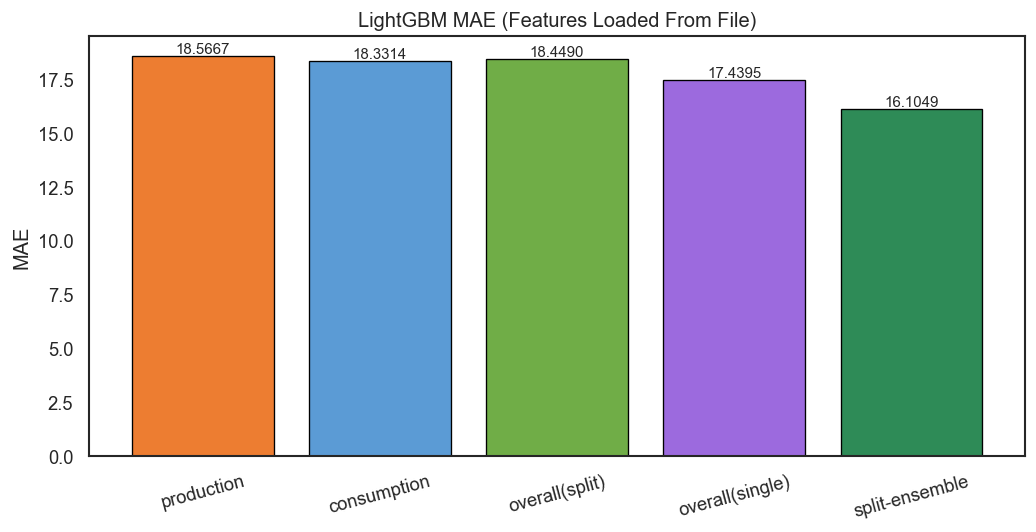

In [12]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
bar_colors = ["#ED7D31", "#5B9BD5", "#70AD47", "#9C6ADE", "#2E8B57"]
bars = ax.bar(mae_result.index, mae_result["MAE"].values, color=bar_colors[:len(mae_result)], edgecolor="black", linewidth=0.8)
ax.set_title("LightGBM MAE (Features Loaded From File)")
ax.set_ylabel("MAE")
ax.grid(False)
ax.tick_params(axis="x", rotation=15)
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_fig(fig, "01_mae_summary.jpg")
plt.show()

In [13]:
# rolling_* 피처별 MAE (production / consumption / overall)
rolling_cols = sorted([c for c in valid_df.columns if c.startswith("rolling_")])

def per_feature_mae(df_p: pd.DataFrame, df_c: pd.DataFrame, feature_list: list[str], feature_name_col: str):
    rows = []
    for col in feature_list:
        if col not in df_p.columns or col not in df_c.columns:
            continue

        p = df_p[[TARGET, col]].dropna()
        c = df_c[[TARGET, col]].dropna()
        o = pd.concat([p, c], axis=0)
        if len(p) == 0 or len(c) == 0:
            continue

        rows.append({
            feature_name_col: col,
            "production": mean_absolute_error(p[TARGET], p[col]),
            "consumption": mean_absolute_error(c[TARGET], c[col]),
            "overall": mean_absolute_error(o[TARGET], o[col]),
        })
    return pd.DataFrame(rows)

rolling_mae_df = per_feature_mae(pred_prod_df, pred_cons_df, rolling_cols, "rolling_feature")
display(rolling_mae_df.style.format({"production": "{:.4f}", "consumption": "{:.4f}", "overall": "{:.4f}"}))

,rolling_feature,production,consumption,overall
0,rolling_mean_12,198.3892,126.1970,162.2931
1,rolling_mean_168,176.0502,133.7359,154.8930
2,rolling_mean_168_solar,203.3963,493.6802,348.5383
3,rolling_mean_168_temp,158.0236,517.0833,337.5535
4,rolling_mean_24,174.6187,117.8107,146.2147
5,rolling_mean_3,87.8073,67.7356,77.7715
6,rolling_mean_48,176.3673,127.6249,151.9961
7,rolling_mean_6,137.8995,96.3683,117.1339
8,rolling_std_12,175.5160,423.7938,299.6549
9,rolling_std_168,204.7314,371.5375,288.1344


saved: c:\Users\AN\Desktop\kaggle\notebooks\LightGBM_codex_figures\02_rolling_feature_mae.jpg


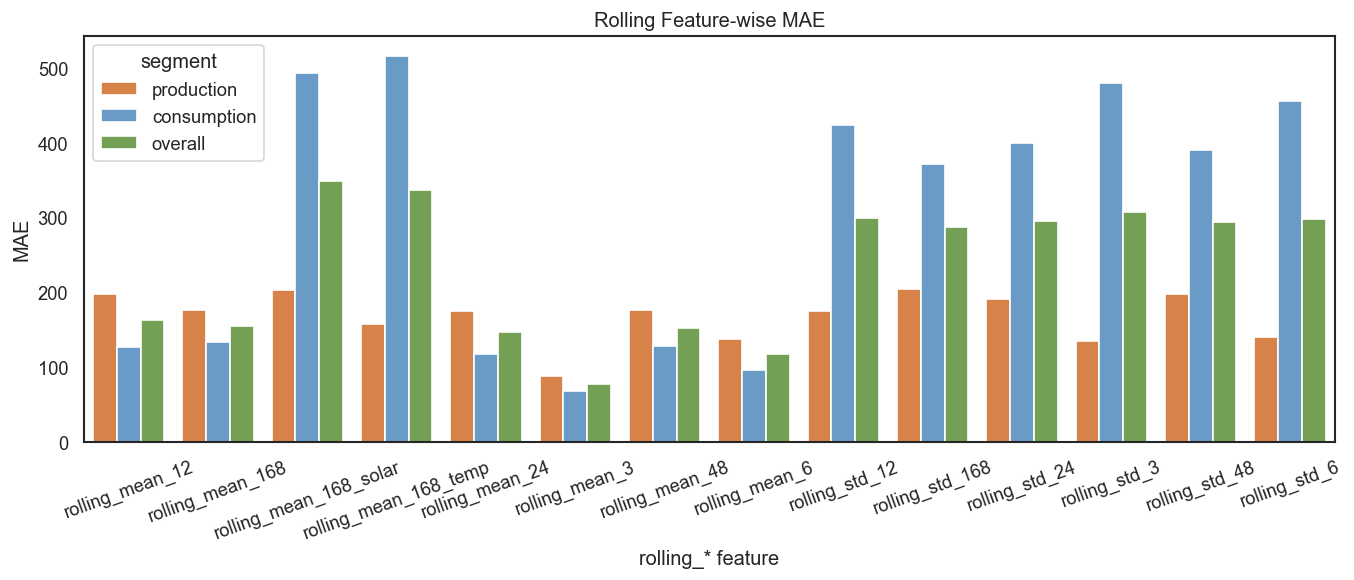

In [14]:
# rolling_* 피처별 MAE 시각화
plot_roll = rolling_mae_df.melt(id_vars="rolling_feature", var_name="segment", value_name="mae")
fig, ax = plt.subplots(figsize=(11.5, 5))
sns.barplot(
    data=plot_roll,
    x="rolling_feature",
    y="mae",
    hue="segment",
    palette={"production": "#ED7D31", "consumption": "#5B9BD5", "overall": "#70AD47"},
    ax=ax,
)
ax.set_title("Rolling Feature-wise MAE")
ax.set_xlabel("rolling_* feature")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=20)
ax.grid(False)
plt.tight_layout()
save_fig(fig, "02_rolling_feature_mae.jpg")
plt.show()

In [15]:
# lag_* 피처별 MAE (production / consumption / overall)
lag_cols = sorted([c for c in valid_df.columns if c.startswith("lag_")])
lag_mae_df = per_feature_mae(pred_prod_df, pred_cons_df, lag_cols, "lag_feature")
display(lag_mae_df.style.format({"production": "{:.4f}", "consumption": "{:.4f}", "overall": "{:.4f}"}))

,lag_feature,production,consumption,overall
0,lag_1,48.3129,42.8199,45.5664
1,lag_12,301.9148,196.1632,249.0390
2,lag_120,85.5211,136.7571,111.1391
3,lag_168,81.6616,87.0544,84.3580
4,lag_2,90.7371,72.5674,81.6523
5,lag_24,64.2330,87.7994,76.0162
6,lag_3,130.0146,98.6995,114.3570
7,lag_48,80.4943,128.4441,104.4692
8,lag_6,226.1404,154.8303,190.4853
9,lag_72,84.1355,140.5353,112.3354


saved: c:\Users\AN\Desktop\kaggle\notebooks\LightGBM_codex_figures\03_lag_feature_mae.jpg


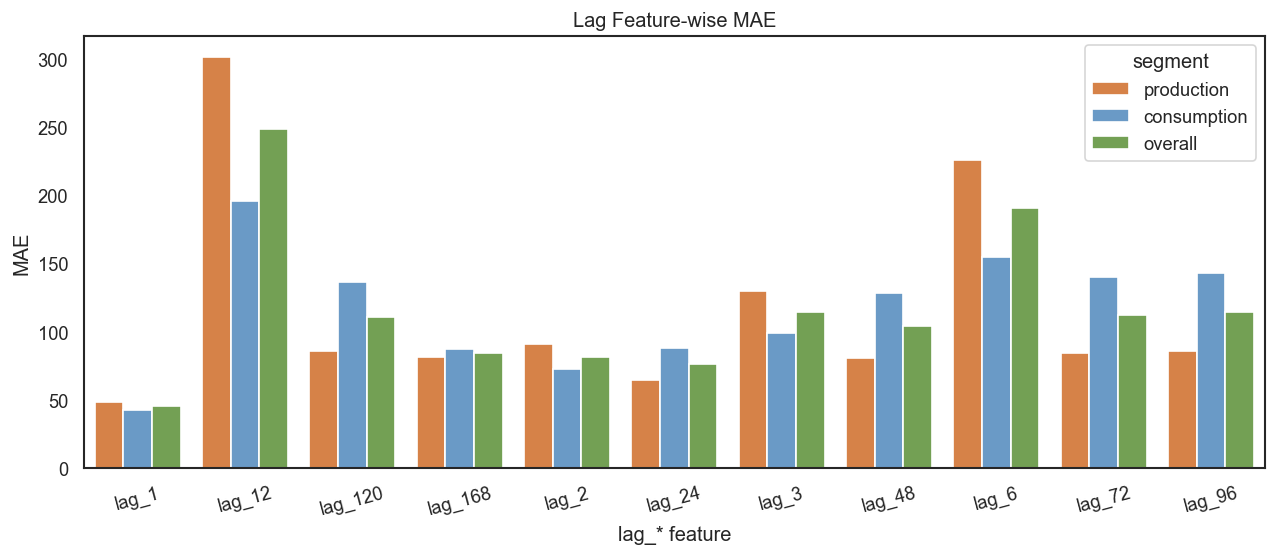

In [16]:
# lag_* 피처별 MAE 시각화
plot_lag = lag_mae_df.melt(id_vars="lag_feature", var_name="segment", value_name="mae")
fig, ax = plt.subplots(figsize=(10.8, 4.8))
sns.barplot(
    data=plot_lag,
    x="lag_feature",
    y="mae",
    hue="segment",
    palette={"production": "#ED7D31", "consumption": "#5B9BD5", "overall": "#70AD47"},
    ax=ax,
)
ax.set_title("Lag Feature-wise MAE")
ax.set_xlabel("lag_* feature")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=15)
ax.grid(False)
plt.tight_layout()
save_fig(fig, "03_lag_feature_mae.jpg")
plt.show()

saved: c:\Users\AN\Desktop\kaggle\notebooks\LightGBM_codex_figures\04_residual_analysis.jpg


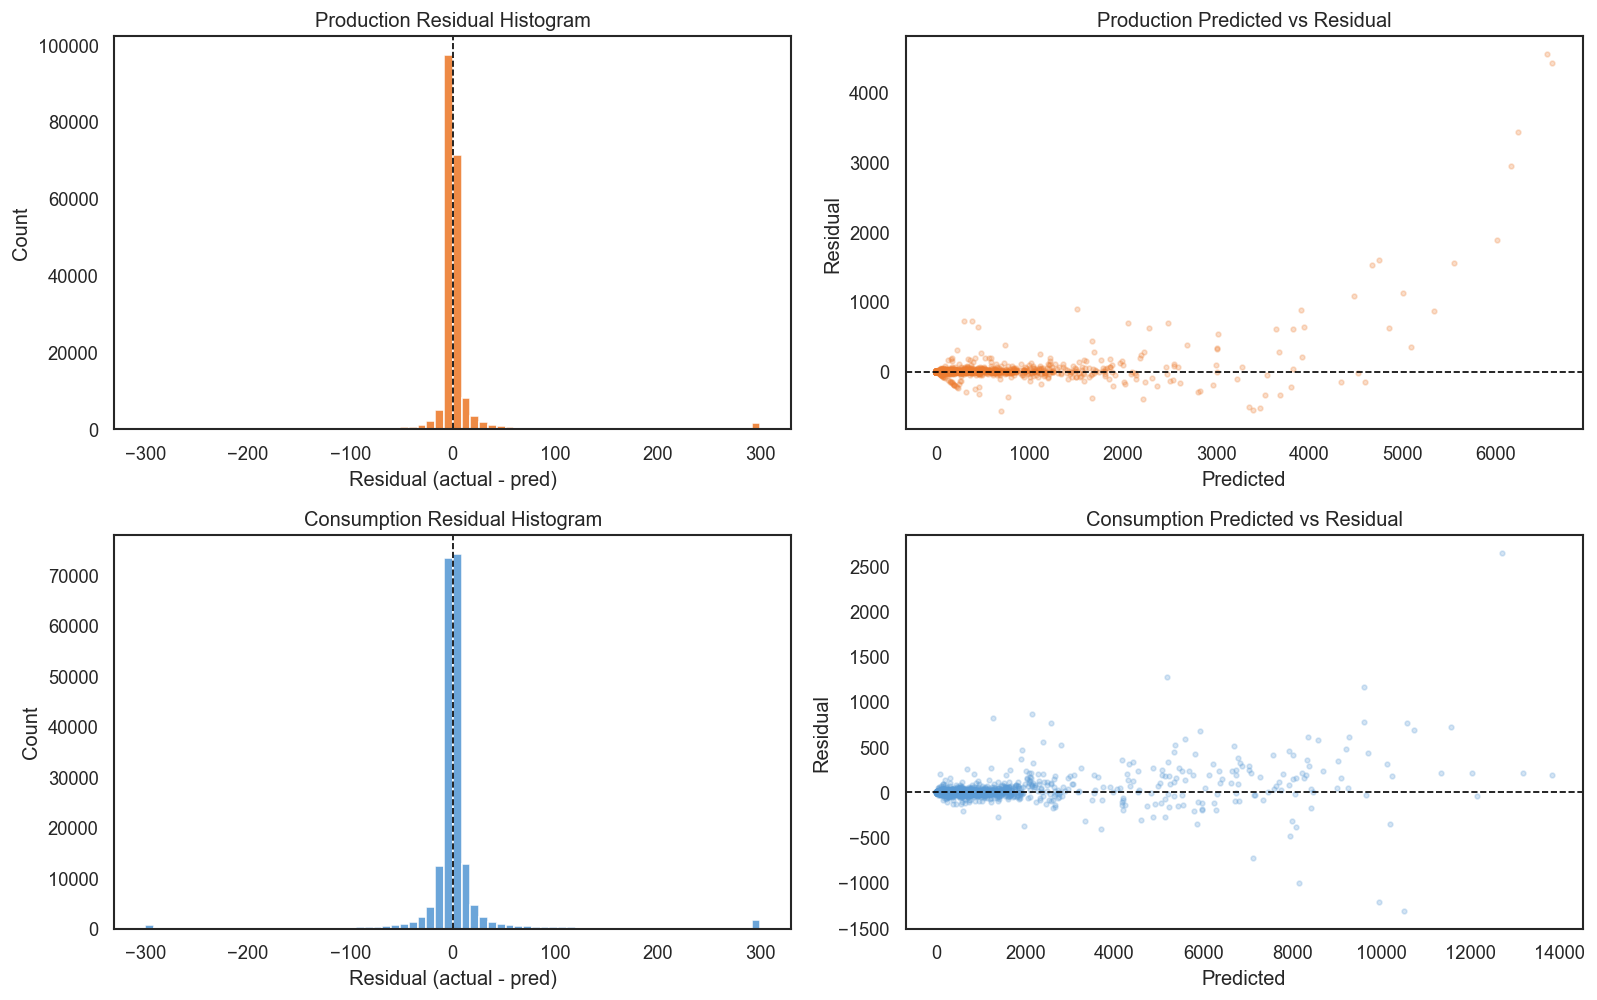

In [17]:
# 잔차 분석 (히스토그램, 예측값-잔차 산점도)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))

for r, (name, df_seg, color) in enumerate([
    ("production", pred_prod_df, "#ED7D31"),
    ("consumption", pred_cons_df, "#5B9BD5"),
]):
    residual = df_seg[TARGET].values - df_seg["pred_lgbm"].values

    axes[r, 0].hist(np.clip(residual, -300, 300), bins=70, color=color, edgecolor="white", alpha=0.9)
    axes[r, 0].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[r, 0].set_title(f"{name.capitalize()} Residual Histogram")
    axes[r, 0].set_xlabel("Residual (actual - pred)")
    axes[r, 0].set_ylabel("Count")
    axes[r, 0].grid(False)

    n = min(5000, len(df_seg))
    idx = np.random.choice(len(df_seg), n, replace=False)
    pred_sample = df_seg["pred_lgbm"].values[idx]
    res_sample = residual[idx]
    axes[r, 1].scatter(pred_sample, res_sample, s=8, alpha=0.25, color=color)
    axes[r, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[r, 1].set_title(f"{name.capitalize()} Predicted vs Residual")
    axes[r, 1].set_xlabel("Predicted")
    axes[r, 1].set_ylabel("Residual")
    axes[r, 1].grid(False)

plt.tight_layout()
save_fig(fig, "04_residual_analysis.jpg")
plt.show()

saved: c:\Users\AN\Desktop\kaggle\notebooks\LightGBM_codex_figures\05_lgbm_feature_importance_prod_cons_overall.jpg


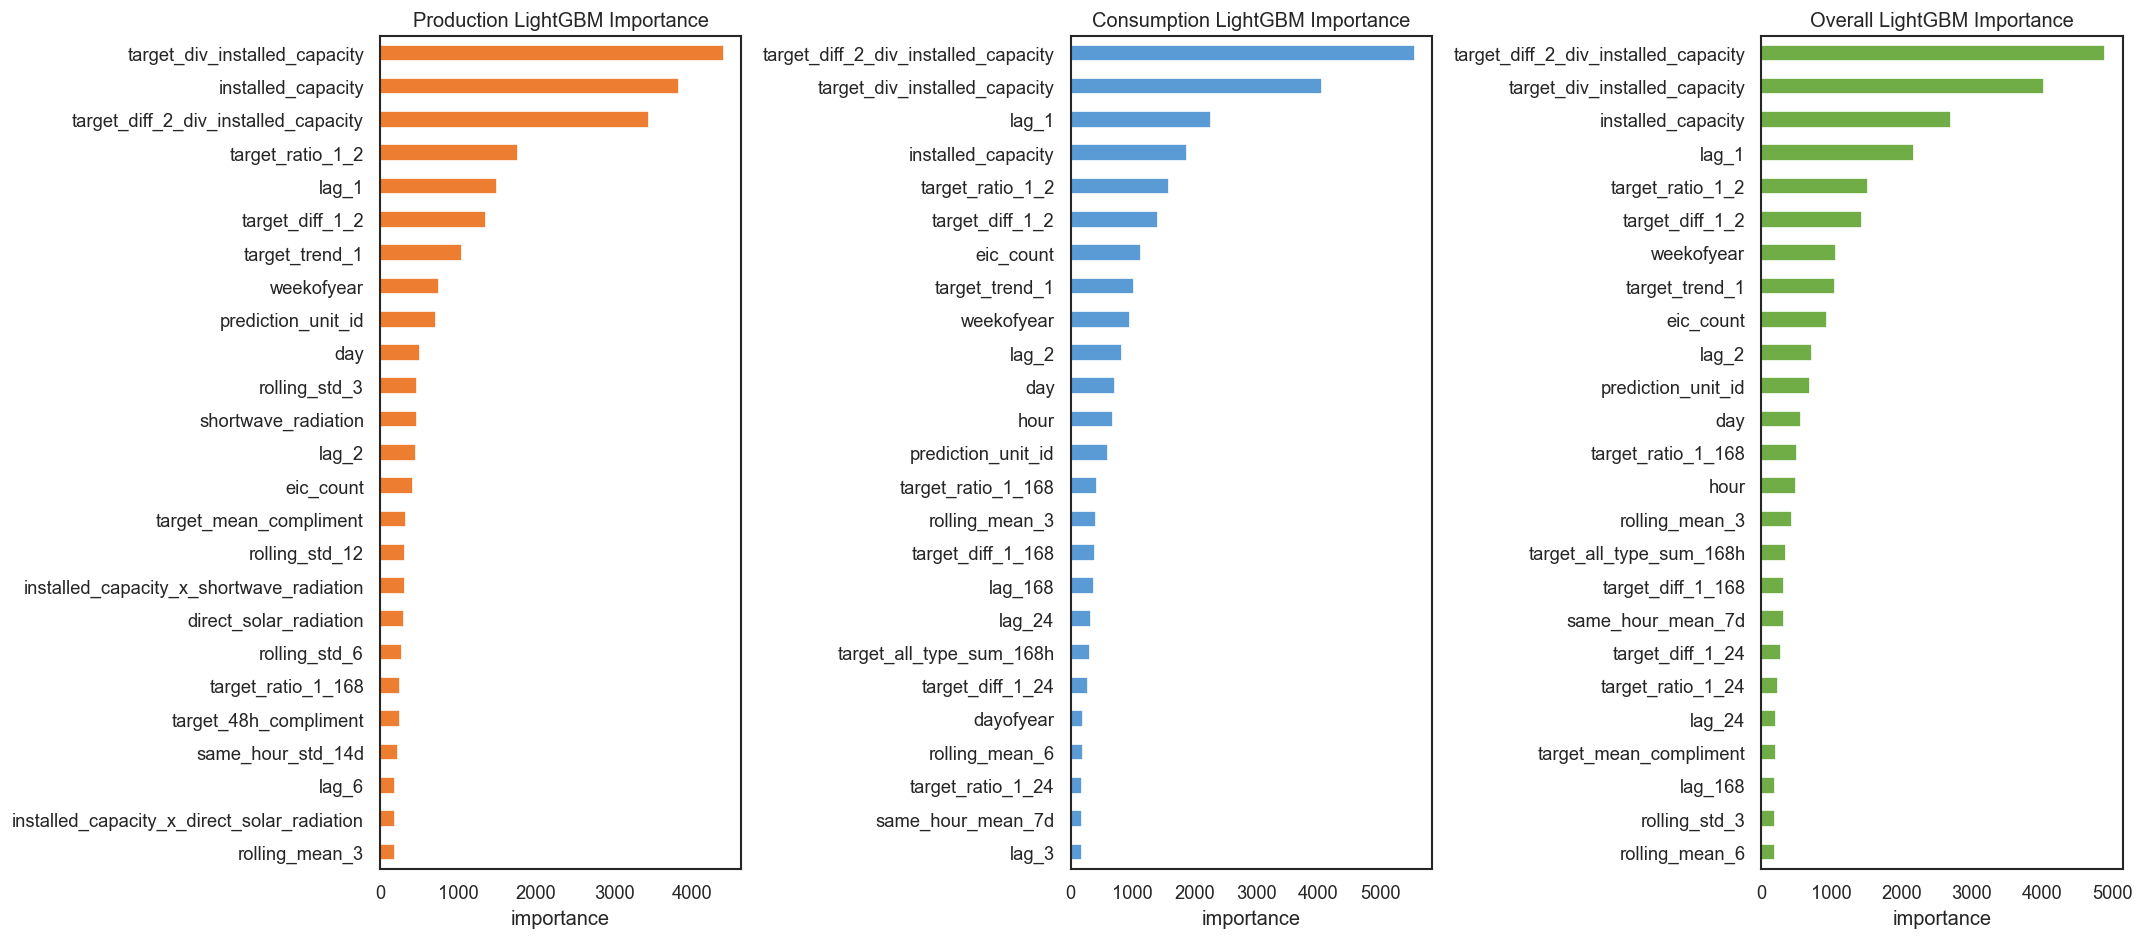

,production_top,consumption_top,overall_top
0,target_div_installed_capacity,target_diff_2_div_installed_capacity,target_diff_2_div_installed_capacity
1,installed_capacity,target_div_installed_capacity,target_div_installed_capacity
2,target_diff_2_div_installed_capacity,lag_1,installed_capacity
3,target_ratio_1_2,installed_capacity,lag_1
4,lag_1,target_ratio_1_2,target_ratio_1_2
5,target_diff_1_2,target_diff_1_2,target_diff_1_2
6,target_trend_1,eic_count,weekofyear
7,weekofyear,target_trend_1,target_trend_1
8,prediction_unit_id,weekofyear,eic_count
9,day,lag_2,lag_2


In [18]:
# LightGBM feature importance (production / consumption / overall)
imp_prod = pd.Series(model_prod.feature_importances_, index=feature_cols).sort_values(ascending=False).head(25)
imp_cons = pd.Series(model_cons.feature_importances_, index=feature_cols).sort_values(ascending=False).head(25)
imp_all = pd.Series(model_all.feature_importances_, index=feature_cols).sort_values(ascending=False).head(25)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, imp, title, color in [
    (axes[0], imp_prod, "Production LightGBM Importance", "#ED7D31"),
    (axes[1], imp_cons, "Consumption LightGBM Importance", "#5B9BD5"),
    (axes[2], imp_all, "Overall LightGBM Importance", "#70AD47"),
]:
    imp.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("importance")
    ax.grid(False)

plt.tight_layout()
save_fig(fig, "05_lgbm_feature_importance_prod_cons_overall.jpg")
plt.show()

display(pd.DataFrame({
    "production_top": imp_prod.index,
    "consumption_top": imp_cons.index,
    "overall_top": imp_all.index,
}))